Submitted by: Marielle Alexa A. Salvador

#Part 1: Finding your data

List the first 3 authors who discovered TOI-6324 b:
- First: Rena A. Lee
- Second: Fei Dai
- Third: Andrew W. Howard

How many systems list position information (RA, Dec) from sources that are not the TICv8 (TESS Input Catalog)?
- It seems that there are 264 in total.

Explore one of these position reference papers. What was the purpose of their survey?
- This paper (AT2021uey: A planetary microlensing event outside the Galactic Bulge) has its purpose that focuses in the discovery and analysis of AT2021uey, also known as Gaia, ZTF, and ASAS-SN, which can only be understood and identify by closely checking at their roles or tasking in a survey like this microlensing event.

Let's now start coding!!!

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [ ]:
dir = '/content'
file = 'NASA Exoplanet Archive_PSCompPars_2025.08.18_22.26.02.csv'
path = os.path.join(dir, file)

df = pd.read_csv(path, comment='#')
df.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


In [ ]:
print(df.columns)

Index(['pl_name', 'hostname', 'sy_snum', 'sy_pnum', 'discoverymethod',
       'disc_year', 'disc_facility', 'pl_controv_flag', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade',
       'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1',
       'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1',
       'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2',
       'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 

In [ ]:
#how many planets are in the table?
num_planets = len(df)
print (f'There are {num_planets} in the table')

There are 5983 in the table


In [ ]:
#how many discovery facilities are listed in the table?
print ('The total number of facilities listed are:', len(df['disc_facility'].unique()))
print ('The name of facilities listed are the following:', df['disc_facility'].unique())

The total number of facilities listed are: 72
The name of facilities listed are the following: ['Xinglong Station' 'Thueringer Landessternwarte Tautenburg'
 'Okayama Astrophysical Observatory' 'W. M. Keck Observatory'
 'Multiple Observatories' 'Lick Observatory' 'Gemini Observatory'
 'Subaru Telescope' 'Paranal Observatory'
 'Cerro Tololo Inter-American Observatory' 'Mauna Kea Observatory'
 'European Space Agency (ESA) Gaia Satellite' 'Hubble Space Telescope'
 'Kepler' 'Haute-Provence Observatory' 'McDonald Observatory'
 'Anglo-Australian Telescope' 'Bohyunsan Optical Astronomical Observatory'
 'Transiting Exoplanet Survey Satellite (TESS)'
 'Roque de los Muchachos Observatory' 'K2'
 'Wide-field Infrared Survey Explorer (WISE) Sat' 'La Silla Observatory'
 'Calar Alto Observatory' 'NASA Infrared Telescope Facility (IRTF)'
 'CoRoT' 'Multiple Facilities' 'Yunnan Astronomical Observatory'
 'Spitzer Space Telescope' 'MEarth Project' 'Very Long Baseline Array'
 'Acton Sky Portal Observatory'

Text(0, 0.5, 'Mass (Jupiter Masses)')

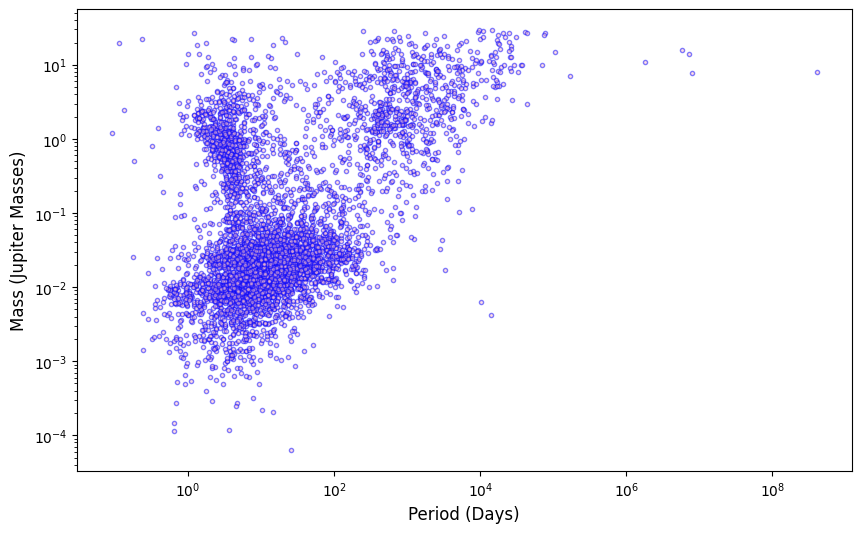

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['pl_orbper'], df['pl_bmassj'], alpha=0.5, color='pink', edgecolor='b', marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Period (Days)', fontsize=12)
plt.ylabel('Mass (Jupiter Masses)', fontsize=12)

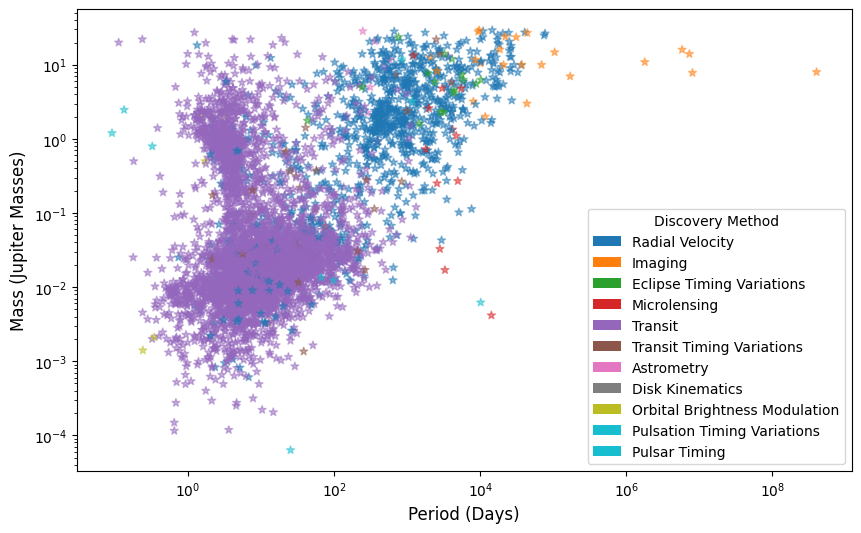

In [ ]:
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Period (Days)', fontsize=12)
plt.ylabel('Mass (Jupiter Masses)', fontsize=12)

discmethods = df['discoverymethod']
dm_num = pd.factorize(discmethods)[0]

cmap = plt.cm.tab10
colors = cmap(dm_num / dm_num.max())
plt.scatter(df['pl_orbper'], df['pl_bmassj'], c=colors, alpha=0.5, marker='*')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i/dm_num.max()), label=label) for i, label in enumerate(discmethods.unique())]
plt.legend(handles=legend_elements, title='Discovery Method', loc='lower right')

Creating another plot

In [ ]:
year_counts = df['disc_year'].value_counts()
print(year_counts)

disc_year
2016    1496
2014     870
2021     555
2022     369
2023     324
2018     313
2024     260
2020     234
2019     197
2015     155
2017     152
2025     146
2012     139
2011     134
2013     128
2010      98
2009      94
2008      63
2007      52
2005      36
2006      32
2002      29
2004      27
2003      22
2000      16
1999      13
2001      12
1998       6
1996       6
1992       2
1995       1
1994       1
1997       1
Name: count, dtype: int64


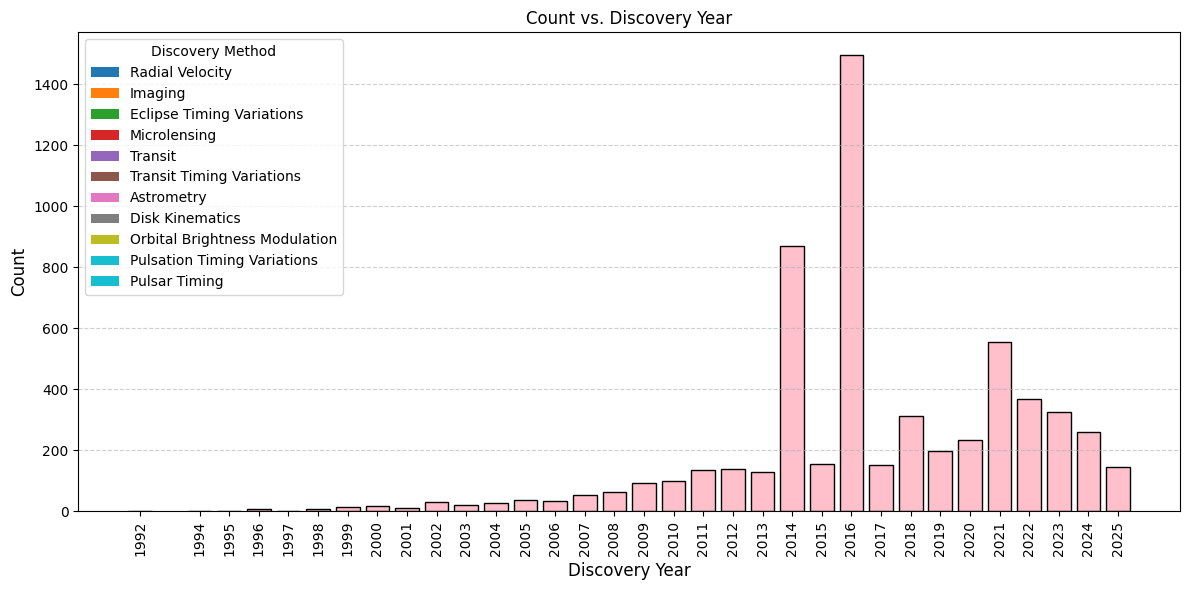

In [ ]:
plt.figure(figsize=(12, 6))
plt.xlabel('Discovery Year', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.bar(year_counts.index, year_counts.values, color='pink', edgecolor='black')
discmethods = df['discoverymethod']
dm_num = pd.factorize(discmethods)[0]
cmap = plt.cm.tab10
colors = cmap(dm_num / dm_num.max())
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i/dm_num.max()), label=label) for i, label in enumerate(discmethods.unique())]
plt.legend(handles=legend_elements, title='Discovery Method', loc='upper left')
plt.title('Count vs. Discovery Year')

plt.xticks(year_counts.index, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
total_counts = year_counts.sum()
print(f"The total number of counts in year_counts is: {total_counts}")

#this checks that the total counts here and the number of exoplanets in the table has the same total

The total number of counts in year_counts is: 5983


#Part 3: Filtering your data

In [ ]:
tess_mask = df['disc_facility'].str.contains('TESS', case=False, na=False)
kepler_mask = df['disc_facility'].str.contains('Kepler', case=False, na=False)

tess_planets = df[tess_mask]
kepler_planets = df[kepler_mask]

print ('The number of planets discovered by TESS is', len(tess_planets))
print ('The number of planets discovered by Kepler is', len(kepler_planets))

The number of planets discovered by TESS is 686
The number of planets discovered by Kepler is 2784


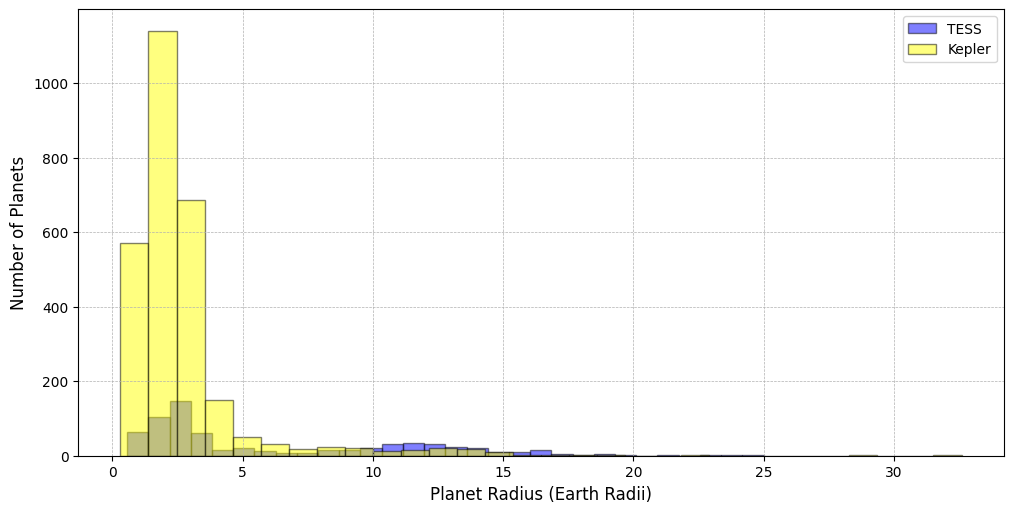

In [ ]:
#histogram of planet radii for TESS & Kepler planets in Earth radii
plt.figure(figsize=(10, 5))
plt.hist(tess_planets['pl_rade'], bins=30, alpha=0.5, label='TESS', color='blue', edgecolor='black')
plt.hist(kepler_planets['pl_rade'], bins=30, alpha=0.5, label='Kepler', color='yellow', edgecolor='black')
plt.grid (True, which = 'both', ls = '--', linewidth = 0.5)
plt.tight_layout()
plt.xlabel('Planet Radius (Earth Radii)',fontsize=12)
plt.ylabel('Number of Planets',fontsize=12)

plt.legend()

In [ ]:
plt.figure(figsize=(10, 5))

bins = np.logspace(np.log10(0.1), np.log10(20), 80)

<Figure size 1000x500 with 0 Axes>

In [ ]:
#What are the most notable differences between the two distributions?
#What are the similarities? Try re-plotting a 'zoomed-in' section of the above histogram to better view the 'radius valley'.

tess_rade_stats = tess_planets['pl_rade'].describe()
kepler_rade_stats = kepler_planets['pl_rade'].describe()

print("Descriptive Statistics for TESS Planet Radii (Earth Radii):")
print(tess_rade_stats)
print("\nDescriptive Statistics for Kepler Planet Radii (Earth Radii):")
print(kepler_rade_stats)

Descriptive Statistics for TESS Planet Radii (Earth Radii):
count    685.000000
mean       6.288053
std        5.197876
min        0.566000
25%        2.220000
50%        3.297013
75%       11.096891
max       25.000000
Name: pl_rade, dtype: float64

Descriptive Statistics for Kepler Planet Radii (Earth Radii):
count    2780.000000
mean        2.700347
std         2.453806
min         0.309800
25%         1.485058
50%         2.140000
75%         2.870000
max        32.600000
Name: pl_rade, dtype: float64


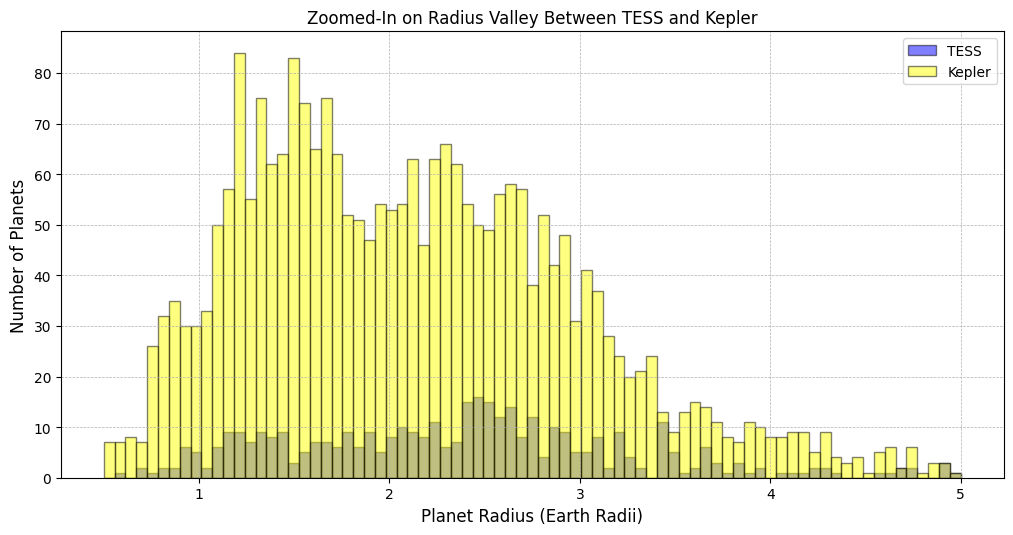

In [ ]:
#this will be the zoomed-in version of the histogram above

bins_zoom = np.linspace(0.5, 5, 80)
plt.figure(figsize=(10, 5))
plt.hist(tess_planets['pl_rade'], bins=bins_zoom, alpha=0.5, label='TESS', color='blue', edgecolor='black')
plt.hist(kepler_planets['pl_rade'], bins=bins_zoom, alpha=0.5, label='Kepler', color='yellow', edgecolor='black')

plt.grid (True, which = 'both', ls = '--', linewidth = 0.5)
plt.tight_layout()
plt.xlabel('Planet Radius (Earth Radii)',fontsize=12)
plt.ylabel('Number of Planets',fontsize=12)
plt.title ('Zoomed-In on Radius Valley Between TESS and Kepler')
plt.legend()

In [ ]:
#this section will answer the following questions:
#how many planets were discovered using the Radial Velocity method?
#how far away is the furthest confirmed exoplanet? What is its name?
#how many planets are smaller than the Earth?

method = df ['discoverymethod'].str.contains('Radial Velocity', case =False, na=False)
radial_velocity_method = df [method]
print ('This is the number of planets discovered using Radial Velocity method:', len (radial_velocity_method))

y=np.amax(df['sy_dist'])
x=df.iloc[np.argmax(df['sy_dist'])]['pl_name']
print (f'The recorded furthest exoplanet is {y} pc. Then, the name of the planet is {x}')

count=0
for x in df ['pl_rade']:
  if x<1:
    count = count+1
print ('Total number of planets smaller than the Earth is', count)

This is the number of planets discovered using Radial Velocity method: 1131
The recorded furthest exoplanet is 8500.0 pc. Then, the name of the planet is SWEEPS-11 b
Total number of planets smaller than the Earth is 226


In [ ]:
mass_and_radius_mask = df['pl_bmasse'].notna() & df['pl_rade'].notna()
chosen_planets = df[mass_and_radius_mask]
new_mask = chosen_planets[(chosen_planets['pl_bmasse'] > 0) & (chosen_planets['pl_rade'] > 0)]
print ('Count of Planets Having Mass and Radius Measurement:', len(chosen_planets))

Count of Planets Having Mass and Radius Measurement: 5937


In [ ]:
import astropy.units as u

rad_cm= new_mask['pl_rade']*u.earthRad.to(u.cm)
mass_g= new_mask['pl_bmasse']*u.earthMass.to(u.g)

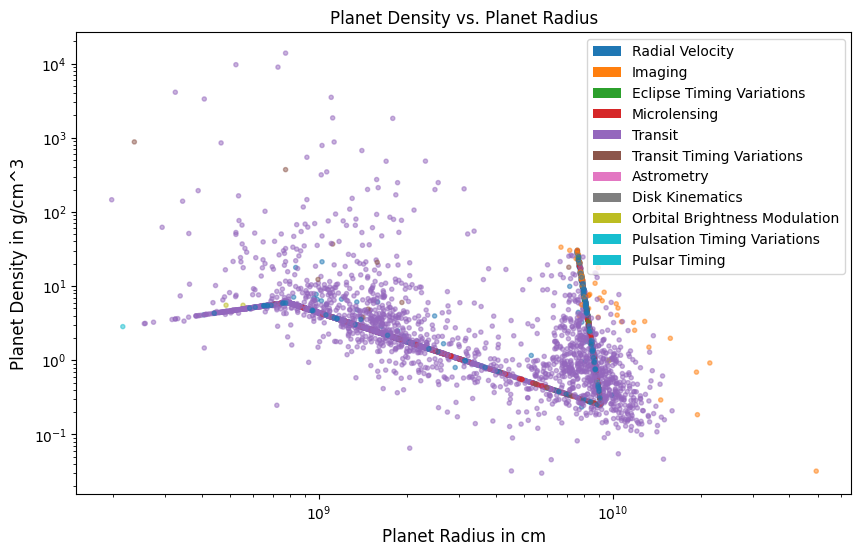

In [ ]:
#its time to calculate density in g/cm^3
dens = mass_g/(4/3 * np.pi * rad_cm**3)
discmethods = new_mask['discoverymethod']
dm_num = pd.factorize(discmethods)[0]

cmap = plt.cm.tab10
colors = cmap(dm_num / dm_num.max())

plt.figure(figsize=(10, 6))
plt.scatter(rad_cm, dens, c=colors, alpha=0.5, marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet Radius (cm)', fontsize=12)
plt.ylabel('Planet Density (g/cm^3)', fontsize=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i/dm_num.max()), label=label) for i, label in enumerate(discmethods.unique())]

plt.xlabel('Planet Radius in cm', fontsize=12)
plt.ylabel('Planet Density in g/cm^3', fontsize=12)
plt.title('Planet Density vs. Planet Radius')
plt.legend(handles=legend_elements)

#Part 4: Choose your own adventure

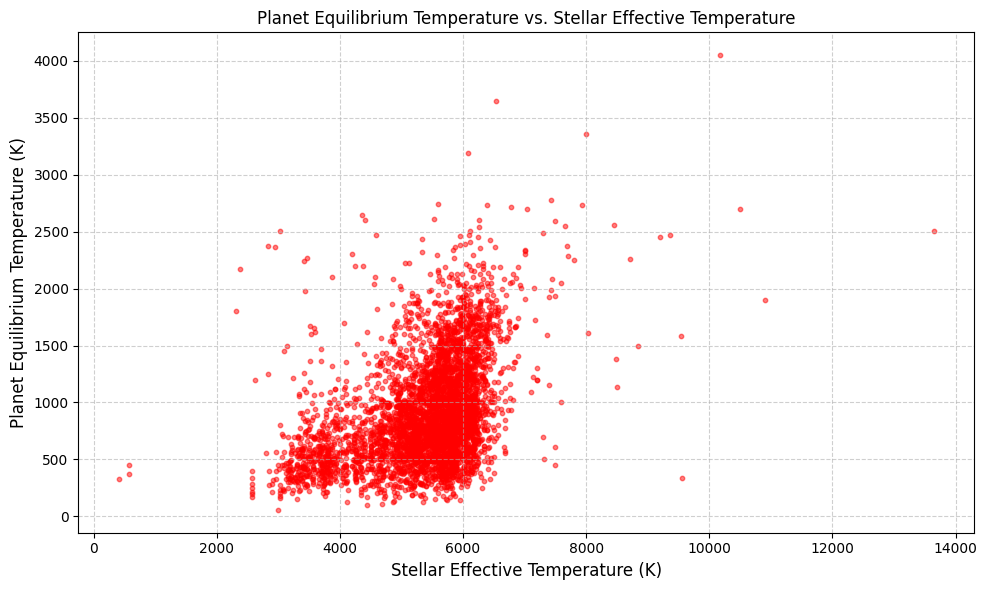

In [ ]:
#let's try the relationship between stellar effective temperature and planet equilibrium temperature
temp_correlation_df = df[df['st_teff'].notna() & df['pl_eqt'].notna()].copy()

plt.figure(figsize=(10, 6))
plt.scatter(temp_correlation_df['st_teff'], temp_correlation_df['pl_eqt'], alpha=0.5, s=10, color='r')

plt.xlabel('Stellar Effective Temperature (K)', fontsize=12)
plt.ylabel('Planet Equilibrium Temperature (K)', fontsize=12)
plt.title('Planet Equilibrium Temperature vs. Stellar Effective Temperature')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
correlation = temp_correlation_df['st_teff'].corr(temp_correlation_df['pl_eqt'])

print(f"Pearson correlation coefficient between Stellar Effective Temperature and Planet Equilibrium Temperature: {correlation}")

Pearson correlation coefficient between Stellar Effective Temperature and Planet Equilibrium Temperature: 0.42474705389509676


The result of pearson correlation was shown at approx. 0.425, which means that there is close connection between the two like how hot a star is and how hot its planet is. Basically, I think it tells that when the star is hotter, then the planet is usually hotter too, but this claim is not fully claimed as a fact since based on the results, also, there is no enough strong connection that can guarantee this claim.

#Write down some interesting things you learned from your plot.

For me, all of these kinda got my attention and interests as an science enthusiast because how come that by doing machine learning, we can now visualized or picturized a scientific data by plotting it using python languages. Doing this helps me see how many different kinds of planets are out there and how we're getting better in developing technology that can help us at finding them and learning what they're like, such as their parameters and characteristics even though they're far light years away from us.
